In [25]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test  = x_test.astype("float32") / 255.

x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

latent_dim = 32

inputs = layers.Input(shape=(784,))
encoded = layers.Dense(latent_dim, activation='relu')(inputs)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(x_train, x_train, epochs=5, batch_size=256, validation_data=(x_test, x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0703 - val_loss: 0.0410
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0351 - val_loss: 0.0295
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0265 - val_loss: 0.0231
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0213 - val_loss: 0.0189
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0179 - val_loss: 0.0162


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


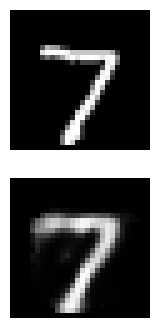

In [26]:
reconstructed = autoencoder.predict(x_test[:1])

plt.figure(figsize=(10,4))
for i in range(1):
    # Original
    plt.subplot(2,1,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,1,i+2)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [27]:
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy, 0., 1.)

inputs = layers.Input(shape=(784,))
encoded = layers.Dense(64, activation='relu')(inputs)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

denoise_ae = Model(inputs, decoded)
denoise_ae.compile(optimizer='adam', loss='mse')

denoise_ae.fit(x_train_noisy, x_train,
               epochs=5, batch_size=256,
               validation_data=(x_test_noisy, x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0614 - val_loss: 0.0357
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0295 - val_loss: 0.0239
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0215 - val_loss: 0.0190
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0179 - val_loss: 0.0162
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0156 - val_loss: 0.0144


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


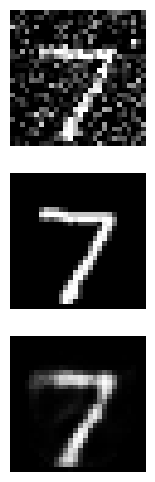

In [28]:
cleaned = denoise_ae.predict(x_test_noisy[:1])

plt.figure(figsize=(10,6))
for i in range(1):
    # Noisy
    plt.subplot(3,1,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Clean (original)
    plt.subplot(3,1,i+2)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(3,1,i+3)
    plt.imshow(cleaned[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [29]:
latent_dim = 2

inputs = layers.Input(shape=(784,))
h = layers.Dense(64, activation='relu')(inputs)

z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Custom layer to add KL divergence loss
class KLDivergenceLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        self.add_loss(tf.keras.backend.mean(kl_loss)) # Add the mean KL loss
        return inputs # Return the inputs unchanged

# Add the KL divergence layer to the model. This layer implicitly adds the KL loss.
# We need to pass through z_mean and z_log_var for the sampling step.
# The layer takes (z_mean, z_log_var) as input and returns them, ensuring they are available for sampling.
z_mean, z_log_var = KLDivergenceLayer()([z_mean, z_log_var])

z = layers.Lambda(sampling)([z_mean, z_log_var])

decoder_h = layers.Dense(64, activation='relu')
decoder_out = layers.Dense(784, activation='sigmoid')

outputs = decoder_out(decoder_h(z))
vae = Model(inputs, outputs)

# Compile the model with only the reconstruction loss.
# The KL divergence loss is already added by KLDivergenceLayer.
vae.compile(optimizer='adam', loss='mse')

# For VAE, x_train serves as both input and target for reconstruction.
vae.fit(x_train, x_train, epochs=5, batch_size=256, validation_data=(x_test, x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1192 - val_loss: 0.0711
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0691 - val_loss: 0.0685
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0680 - val_loss: 0.0680
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0677 - val_loss: 0.0678
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0675 - val_loss: 0.0677


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


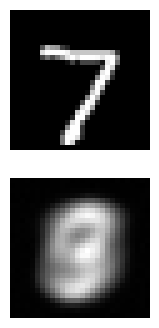

In [30]:
reconstructed = vae.predict(x_test[:1])

plt.figure(figsize=(10,4))
for i in range(1):
    plt.subplot(2,1,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,1,i+2)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

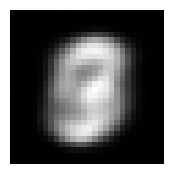

In [31]:
z_sample = np.random.normal(size=(5, latent_dim))
generated = decoder_out(decoder_h(z_sample))

plt.figure(figsize=(10,2))
for i in range(1):
    plt.subplot(1,1,i+1)
    plt.imshow(generated[i].numpy().reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()